# 03 — Disease Progression: Survival Analysis and State Transitions

Model disease trajectories using **Cox Proportional Hazards** and a **continuous-time Markov chain** (CTMC). Show how survival curves and state occupation probabilities translate to underwriting endpoints.

The core question: **where are patients going?** A single risk score captures current severity, but underwriting also needs to know how quickly patients progress through disease stages — and whether that progression is predictable from baseline covariates.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from medrisk.data.synthetic import generate_cohort, cohort_to_dataframe
from medrisk.features.engineering import build_feature_matrix, get_targets
from medrisk.models.cox_ph import CoxPHModel, fit_kaplan_meier
from medrisk.models.multistate import MultistateModel, STATE_NAMES

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
cohort = generate_cohort(n_per_market=500, seed=42)
df = cohort_to_dataframe(cohort)
X, feature_names = build_feature_matrix(df)
print(f"Cohort: {len(df)} patients, {df['event_occurred'].sum()} events")

Cohort: 2000 patients, 18 events


## Overall survival

Kaplan-Meier curves give a non-parametric estimate of the survival function — the probability of remaining event-free as a function of time. We stratify by market to see whether progression rates differ structurally across healthcare systems.

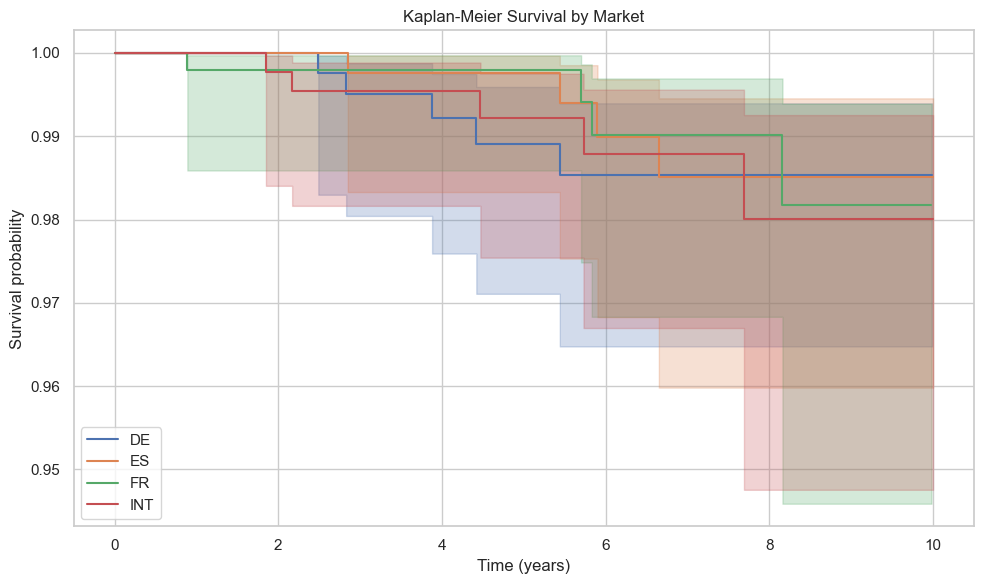

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for market in ["DE", "ES", "FR", "INT"]:
    mask = df["market"] == market
    kmf = fit_kaplan_meier(
        df.loc[mask, "time_to_event"].values,
        df.loc[mask, "event_occurred"].astype(int).values,
        label=market,
    )
    kmf.plot_survival_function(ax=ax)
ax.set_xlabel("Time (years)")
ax.set_ylabel("Survival probability")
ax.set_title("Kaplan-Meier Survival by Market")
plt.tight_layout()
plt.show()

## Cox PH: which covariates drive hazard?

The Cox proportional hazards model estimates the effect of covariates on the hazard rate without assuming a specific baseline hazard shape. Hazard ratios > 1 indicate increased risk; < 1 indicate protective effects. The concordance index measures how well the model ranks patients by risk.

In [4]:
cox_features = ["age", "bmi", "sex_male", "charlson_index", "smoking_current"]
# Add some diagnosis flags that are available
for col in feature_names:
    if col.startswith("has_") and col in ["has_diabetes", "has_hypertension", "has_ihd", "has_copd"]:
        cox_features.append(col)

# Combine engineered features with survival columns from raw df
cox_df = X.copy()
cox_df["time_to_event"] = df["time_to_event"].values
cox_df["event_occurred"] = df["event_occurred"].values

cox = CoxPHModel(penalizer=0.01)
cox.fit(cox_df, feature_cols=cox_features)
print(f"Concordance index: {cox.concordance_index:.4f}")
print("\nHazard Ratios:")
print(cox.hazard_ratios())

Concordance index: 0.8745

Hazard Ratios:
covariate
age                 1.031738
bmi                 1.020792
sex_male            1.451599
charlson_index      1.209639
smoking_current     1.146120
has_copd            0.908315
has_diabetes        1.383449
has_hypertension    1.643472
has_ihd             0.850576
Name: coef, dtype: float64


## CTMC: disease state transitions

A continuous-time Markov chain models disease progression through five states: **Healthy** (0), **Risk factors** (1), **Chronic condition** (2), **Complication** (3), and **Major event** (4, absorbing). The intensity matrix Q governs the instantaneous rates of transition between states.

In [5]:
msm = MultistateModel()
msm.set_intensities({
    (0, 1): 0.08,
    (1, 0): 0.02,
    (1, 2): 0.06,
    (2, 3): 0.04,
    (2, 4): 0.01,
    (3, 4): 0.03,
})

print("Transition intensities:")
for trans, rate in msm.get_intensity_summary().items():
    print(f"  {trans}: {rate:.4f}")

Transition intensities:
  Healthy -> Risk factors: 0.0800
  Risk factors -> Healthy: 0.0200
  Risk factors -> Chronic condition: 0.0600
  Chronic condition -> Complication: 0.0400
  Chronic condition -> Major event: 0.0100
  Complication -> Major event: 0.0300


## State occupation probabilities over time

Starting from the Healthy state, how does the probability mass redistribute across disease stages over a 30-year horizon? The stacked area chart shows the expected population distribution at each time point — this is the key input for long-term pricing models.

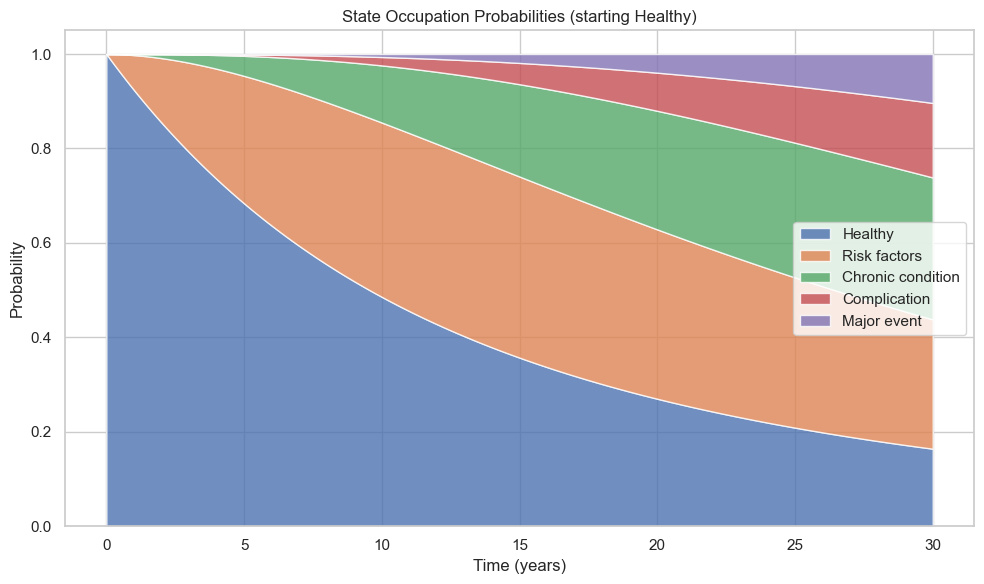

In [6]:
times = np.linspace(0, 30, 200)
probs = msm.state_occupation_probabilities(0, times)

fig, ax = plt.subplots(figsize=(10, 6))
labels = [STATE_NAMES[i] for i in range(5)]
ax.stackplot(times, probs.T, labels=labels, alpha=0.8)
ax.set_xlabel("Time (years)")
ax.set_ylabel("Probability")
ax.set_title("State Occupation Probabilities (starting Healthy)")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

In [7]:
print("Mean time to major event (absorbing state):")
for s in range(4):
    mat = msm.mean_time_to_absorption(s)
    print(f"  From {STATE_NAMES[s]}: {mat:.1f} years")

Mean time to major event (absorbing state):
  From Healthy: 80.0 years
  From Risk factors: 67.5 years
  From Chronic condition: 46.7 years
  From Complication: 33.3 years


## Individual patient trajectories

The CTMC generates individual disease trajectories via the Gillespie algorithm. Each step function shows one patient's path through the state space — some progress rapidly to a major event, others remain stable or even recover from risk factor states.

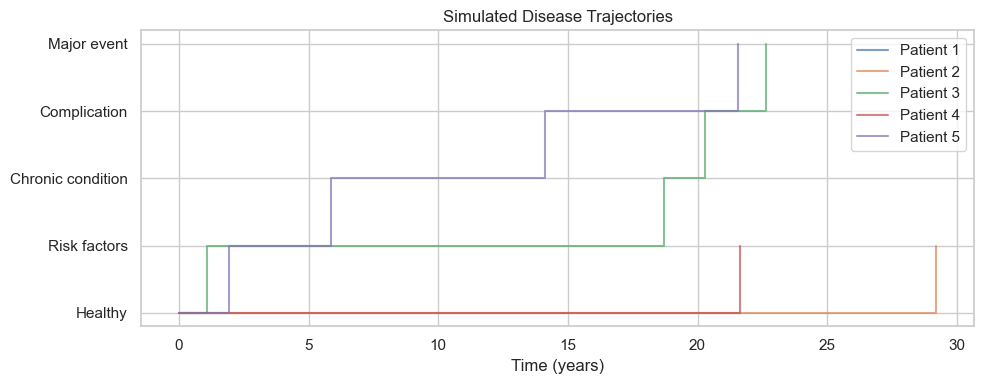

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
rng = np.random.default_rng(42)
for i in range(5):
    traj = msm.simulate_trajectory(0, 30.0, rng=rng)
    t_vals = [t for t, s in traj]
    s_vals = [s for t, s in traj]
    ax.step(t_vals, s_vals, where="post", alpha=0.7, label=f"Patient {i+1}")
ax.set_yticks(range(5))
ax.set_yticklabels([STATE_NAMES[i] for i in range(5)])
ax.set_xlabel("Time (years)")
ax.set_title("Simulated Disease Trajectories")
ax.legend()
plt.tight_layout()
plt.show()

## Key finding

Patients with similar XGBoost risk scores can have very different disease trajectories. A patient at risk state 2 (chronic condition) may progress rapidly to a major event or remain stable for years. The multistate model captures this trajectory information that a single risk score cannot.

The combination of **Cox PH** (which covariates accelerate progression) and **CTMC** (which state-to-state paths are most likely) gives underwriters two complementary views: relative hazard for ranking and state occupation probabilities for reserving.